In [3]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE

with open("code_corpus.json", encoding="utf-8") as f:
    corpus = json.load(f)
with open("eval_questions.json", encoding="utf-8") as f:
    questions = json.load(f)
with open("categories.json", encoding="utf-8") as f:
    categories = json.load(f)["categories"]

assert len(corpus) == 200, f"corpus: {len(corpus)}"
assert len(questions) == 25, f"questions: {len(questions)}"
assert len(categories) == 5, f"categories: {len(categories)}"

ids = [f["id"] for f in corpus]
assert len(ids) == len(set(ids)), "duplicate ids"

corpus_ids = set(ids)
for q in questions:
    assert q["correct_chunk_id"] in corpus_ids, f"missing: {q['correct_chunk_id']}"

for f in corpus[:100]:
    assert f["language"] == "python"
for f in corpus[100:]:
    assert f["language"] == "java"

print("✓ Все проверки пройдены")

corpus_txt = [f"{i['function_name']}: {i['description']}" for i in corpus]
corpus_ids = [i["id"] for i in corpus]
corpus_categories = [i["category"] for i in corpus]

questions_txt = [f"{i['query']}" for i in questions]
questions_correct_ids = [i["correct_chunk_id"] for i in questions]
questions_categories = [i["language"] for i in questions]

models = {
    "MiniLM": "paraphrase-multilingual-MiniLM-L12-v2",
    "MPNet": "paraphrase-multilingual-mpnet-base-v2"
}

models_loaded = {}

for model_name, model in models.items():
    print(f"загрузка модели: {model_name}")
    start_time = time.time()
    models_loaded[model_name] = SentenceTransformer(model)
    print(f"модель {model_name} загружена за {time.time() - start_time:.2f} секунд")

✓ Все проверки пройдены
загрузка модели: MiniLM


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

модель MiniLM загружена за 9.97 секунд
загрузка модели: MPNet


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

модель MPNet загружена за 12.80 секунд


In [5]:
def generate_emb_and_search(model, model_name, corpus_txt, questions_txt):
    start_time = time.time()
    corpus_emb = model.encode(corpus_txt, convert_to_tensor=True, show_progress_bar=True)
    questions_emb = model.encode(questions_txt, convert_to_tensor=True, show_progress_bar=True)
    emb_time = time.time() - start_time
    similar = util.cos_sim(questions_emb, corpus_emb).cpu().numpy()
    top = np.argsort(-similar, axis=1)
    top3 = top[:, :3]
    np.save(f"emb_{model_name}.npy", corpus_emb.cpu().numpy())
    return top3, top, emb_time

results = {}

for model_name, model in models_loaded.items():
    print(f"поиск для модели: {model_name}")
    top3, top, emb_time = generate_emb_and_search(model, model_name, corpus_txt, questions_txt)
    results[model_name] = {
        "top3": top3,
        "top": top,
        "embedding_time": emb_time
    }
    print(f"результаты для модели {model_name} сохранены за {emb_time:.2f} секунд")

поиск для модели: MiniLM


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

результаты для модели MiniLM сохранены за 0.79 секунд
поиск для модели: MPNet


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

результаты для модели MPNet сохранены за 2.68 секунд


In [7]:
def precision3(top_m, corpus_ids, questions_correct_ids):
    top3_questions = top_m[:, :3]
    correct = 0
    for i, correct_id in enumerate(questions_correct_ids):
        ids = [corpus_ids[j] for j in top3_questions[i]]
        if correct_id in ids:
            correct += 1
    return correct / len(questions_correct_ids)

justrows = []
for model_name, result in results.items():
    prec3 = precision3(result["top"], corpus_ids, questions_correct_ids)
    justrows.append({
        "модель": model_name,
        "precision@3": round(prec3, 3),
        "Время генерации (с)": round(results[model_name]["embedding_time"], 2)
    })

comparison = pd.DataFrame(justrows).sort_values("precision@3", ascending=False)
comparison.to_csv("model_comparison.csv", index=False)
comparison

,модель,precision@3,Время генерации (с)
1,MPNet,0.92,2.68
0,MiniLM,0.84,0.79


In [8]:
error_check = comparison.iloc[0]["модель"]
top3 = results[error_check]["top"][:, :3]

errors = []
for i, question in enumerate(questions):
    ids = [corpus_ids[j] for j in top3[i]]
    if question["correct_chunk_id"] not in ids:
        correct_func = next(j for j in corpus if j["id"] == question["correct_chunk_id"])
        errors.append({
            "вопрос": question["query"],
            "язык": question["language"],
            "ожидаемая категория": correct_func["category"],
            "ожидаемая функция": correct_func["function_name"],
        })

errors_df = pd.DataFrame(errors)
print(f"Ошибок у модели {error_check}: {len(errors_df)} из {len(questions)}")

if len(errors_df) > 0:
    print("Ошибки по категориям:")
    print(errors_df["ожидаемая категория"].value_counts())
    print()
    print("Ошибки по языку запроса:")
    print(errors_df["язык"].value_counts())
errors_df

Ошибок у модели MPNet: 2 из 25
Ошибки по категориям:
ожидаемая категория
auth     1
utils    1
Name: count, dtype: int64

Ошибки по языку запроса:
язык
ru    1
en    1
Name: count, dtype: int64


,вопрос,язык,ожидаемая категория,ожидаемая функция
0,"как проверить, истёк ли токен?",ru,auth,verify_jwt_token
1,compute file hash for verification,en,utils,calculateHash


In [9]:
langs = []
for model_name, result in results.items():
    for lang in ["ru", "en"]:
        idx = [i for i, l in enumerate(questions_categories) if l == lang]
        sub_top = result["top"][idx]
        sub_correct_ids = [questions_correct_ids[i] for i in idx]
        prec3_lang = precision3(sub_top, corpus_ids, sub_correct_ids)
        langs.append({
            "модель": model_name,
            "язык": lang,
            "precision@3": round(prec3_lang, 3),
            "кол-во вопросов": len(idx)
        })

lang_df = pd.DataFrame(langs)
lang_df

,модель,язык,precision@3,кол-во вопросов
0,MiniLM,ru,0.800,15
1,MiniLM,en,0.900,10
2,MPNet,ru,0.933,15
3,MPNet,en,0.900,10


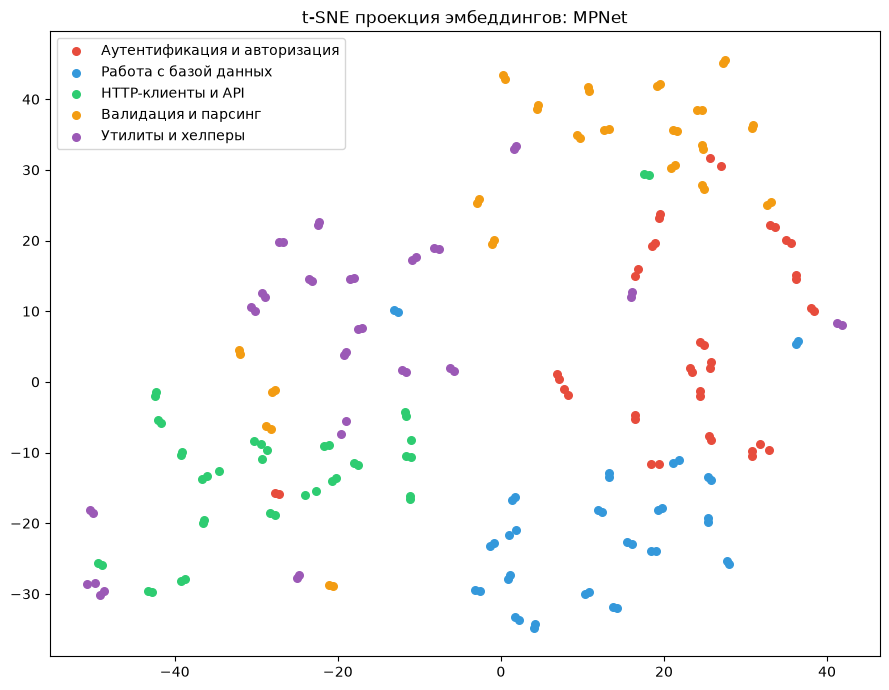

In [12]:
categories_colors = {c["key"]: c["color"] for c in categories}
categories_labels = {c["key"]: c["label"] for c in categories}

best_model = comparison.iloc[0]["модель"]
best_emb = np.load(f"emb_{best_model}.npy")

settings = TSNE(n_components=2, random_state=100, perplexity=5).fit_transform(best_emb)
plt.figure(figsize=(9, 7))

for i in categories_colors:
    mask = np.array([c == i for c in corpus_categories])
    plt.scatter(settings[mask, 0], settings[mask, 1], c=categories_colors[i], label=categories_labels[i], s=30)
plt.title(f"t-SNE проекция эмбеддингов: {best_model}")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("tsne.png")
plt.show()

In [15]:
first_place = comparison.iloc[0]["модель"]
second_place = comparison.iloc[1]["модель"]

first_score = comparison.iloc[0]["precision@3"]
second_score = comparison.iloc[1]["precision@3"]

conclusion = (
    f"В ходе исследования были сравнены модели {first_place} и {second_place}.\n"
    f"По результатам сравнения, модель {first_place} показала Precision@3 = {first_score}, "
    f"что лучше, чем у модели {second_place} (Precision@3 = {second_score}).\n"
    f"t-SNE-проекции эмбеддингов обеих моделей показывают схожую кластеризацию по категориям, "
    f"поэтому решающим критерием при выборе модели стала метрика Precision@3, а не визуальное сравнение.\n"
    f"Сравнение качества поиска на русских и английских вопросах показало, что модель {first_place} и {second_place} "
    f"работают одинаково на английском языке, однако модель {second_place} теряет в точности на русском языке.\n"
    f"Несмотря на большее время выполнения, рекомендуется выбрать модель {first_place}, так как для задачи "
    "семантического поиска приоритетным критерием является точность поиска."
)
print(conclusion)

with open("conclusion.txt", "w", encoding="utf-8") as f:
    f.write(conclusion)

В ходе исследования были сравнены модели MPNet и MiniLM.
По результатам сравнения, модель MPNet показала Precision@3 = 0.92, что лучше, чем у модели MiniLM (Precision@3 = 0.84).
t-SNE-проекции эмбеддингов обеих моделей показывают схожую кластеризацию по категориям, поэтому решающим критерием при выборе модели стала метрика Precision@3, а не визуальное сравнение.
Сравнение качества поиска на русских и английских вопросах показало, что модель MPNet и MiniLM работают одинаково на английском языке, однако модель MiniLM теряет в точности на русском языке.
Несмотря на большее время выполнения, рекомендуется выбрать модель MPNet, так как для задачи семантического поиска приоритетным критерием является точность поиска.
